## Cell 1 — Install & Import

In [ ]:
!pip install lightgbm xgboost catboost scikit-learn pandas numpy scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb

try:
    from catboost import CatBoostRegressor
    USE_CATBOOST = True
    print("CatBoost sẵn sàng")
except ImportError:
    USE_CATBOOST = False
    print("CatBoost chưa cài — chạy: pip install catboost")
    print("   Ensemble sẽ chỉ dùng LightGBM + XGBoost")

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

print("Import thành công!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00
CatBoost sẵn sàng
Import thành công!


## Cell 2 — Load & Audit

In [ ]:
!gdown https://drive.google.com/uc?id=1ppvLqTXnn8smkdcc51qCv18kEinCZnCP

df_raw = pd.read_csv('data_final_cleaned.csv')
print(f"Shape gốc: {df_raw.shape}")

price_m2 = df_raw['price_per_m2_vnd'] / 1e6
print(f"\nprice/m² — min: {price_m2.min():.3f}  max: {price_m2.max():.0f}  "
      f"median: {price_m2.median():.1f}  skew: {price_m2.skew():.2f}")
print(f"price/m² < 2 triệu  : {(price_m2 < 2).sum()} rows")
print(f"price/m² > 1200 triệu: {(price_m2 > 1200).sum()} rows")
print(f"area_m2 < 15m²       : {(df_raw['area_m2'] < 15).sum()} rows")

miss = df_raw.isnull().sum().sort_values(ascending=False)
print(f"\nMissing values (top 15):")
print(miss[miss > 0].head(15).to_string())

Downloading...
From: https://drive.google.com/uc?id=1ppvLqTXnn8smkdcc51qCv18kEinCZnCP
To: /content/data_final_cleaned.csv
100% 59.1M/59.1M [00:01<00:00, 59.0MB/s]
Shape gốc: (5669, 51)

price/m² — min: 22.917  max: 638  median: 63.0  skew: 2.84
price/m² < 2 triệu  : 0 rows
price/m² > 1200 triệu: 0 rows
area_m2 < 15m²       : 0 rows

Missing values (top 15):
Series([], )


## Cell 3 — Làm sạch

In [ ]:
df = df_raw.copy()
n0 = len(df)

df = df[
    (df['price_per_m2_vnd'] >= 5e6) &
    (df['price_per_m2_vnd'] <= 1200e6) &
    (df['area_m2'] >= 15) &
    (df['area_m2'] <= 2000)
].copy()
print(f"Sau lọc data lỗi: {len(df)} rows (đã loại {n0 - len(df)} rows)")

# Outlier filter
mask_small_crowd = (df['area_m2'] < 50) & (df['bedrooms'] >= 3)
_proj_mean = df.groupby('project_name')['price_per_m2_vnd'].transform('mean')
_proj_std  = df.groupby('project_name')['price_per_m2_vnd'].transform('std').replace(0, 1e-6)
_z_project = (df['price_per_m2_vnd'] - _proj_mean) / _proj_std
mask_extreme = (_z_project.abs() > 7) & (df['price_per_m2_vnd'] > 500e6)
mask_remove  = mask_small_crowd | mask_extreme
df = df[~mask_remove].copy()
print(f"Sau outlier filter: {len(df)} rows")

DROP_ALWAYS = [
    'note', 'source_listing_id', 'listing_url', 'source_url',
    'project_id', 'contact_name', 'contact_phone_masked',
    'address', 'city', 'expired_at',
    'project_description', 'street', 'source_name', 'project_status', 'longitude', 'latitude', 'title', 'listing_description'
]
df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns], inplace=True)

for col in ['posted_at', 'snapshot_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

def normalize_ownership(x):
    if pd.isna(x): return 'Unknown'
    x = str(x).lower()
    if 'lâu dài' in x or 'vĩnh viễn' in x: return 'So_hong_lau_dai'
    if 'từng căn' in x:                      return 'So_hong_tung_can'
    if 'sổ hồng' in x:                       return 'So_hong_khac'
    return 'Khac'

df['ownership'] = df['ownership'].apply(normalize_ownership)
df['direction'] = df['direction'].fillna('Chua_ro')
df['ward']      = df['ward'].str.strip().str.lower().str.title()

print(f"Shape sau clean: {df.shape}")

Sau lọc data lỗi: 5669 rows (đã loại 0 rows)
Sau outlier filter: 5659 rows
Shape sau clean: (5659, 37)


## Cell 4 — Imputation functions (fit sau khi split)

In [ ]:
# ── Check Null sau Cell 3 ──────────────────────────────────────────────────
print(f"Shape: {df.shape}")
print(f"Tổng null toàn bộ: {df.isnull().sum().sum()}\n")

miss = df.isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]

if len(miss) == 0:
    print("Không có null nào!")
else:
    print(f"Có {len(miss)} cột bị null:\n")
    miss_df = pd.DataFrame({
        'null_count': miss,
        'null_pct':   (miss / len(df) * 100).round(2),
        'dtype':      df[miss.index].dtypes
    })
    print(miss_df.to_string())

Shape: (5659, 37)
Tổng null toàn bộ: 0

Không có null nào!


In [ ]:
def fit_imputer(df_train):
    imp = {}

    imp['proj_median_area'] = (
        df_train.groupby('project_name')['area_m2'].median().to_dict()
    )
    imp['global_median_area'] = df_train['area_m2'].median()

    return imp


def apply_imputer(df_in, imp):
    df_out = df_in.copy()

    df_out['proj_median_area'] = (
        df_out['project_name']
        .map(imp['proj_median_area'])
        .fillna(imp['global_median_area'])
    )

    return df_out


print("Imputation functions định nghĩa xong.")

Imputation functions định nghĩa xong.


## Cell 5 — Feature Engineering

In [ ]:
def build_features(df_in):
    """
    Tạo features mới — không dùng target.
    """
    df_out = df_in.copy()

    # Date features
    df_out['posted_month']   = df_out['posted_at'].dt.month
    df_out['posted_year']    = df_out['posted_at'].dt.year.fillna(2025).astype(int)
    df_out['posted_quarter'] = df_out['posted_at'].dt.quarter
    df_out['listing_age_days'] = (
        df_out['snapshot_date'] - df_out['posted_at']
    ).dt.days.clip(lower=0).fillna(0)

    # Project timing
    df_out['project_age_years'] = df_out['posted_year'] - df_out['launch_year']
    df_out['years_to_handover'] = (
        df_out['handover_year'] - df_out['posted_year']
    ).clip(-5, 10)

    # build_duration = handover_year - launch_year ─────────
    # Khác với years_to_handover (handover - posted):
    # build_duration đo thời gian xây dựng → proxy cho quy mô & chất lượng dự án
    # Dự án lớn/phức tạp thường có build_duration dài hơn
    df_out['build_duration'] = (
        df_out['handover_year'] - df_out['launch_year']
    ).clip(0, 15)

    # Room features
    df_out['room_total']     = df_out['bedrooms'] + df_out['bathrooms']
    df_out['bed_bath_ratio'] = df_out['bedrooms'] / (df_out['bathrooms'] + 0.5)
    df_out['area_per_room']  = df_out['area_m2'] / (df_out['room_total'] + 1)

    # Amenity composite
    amenity_cols = ['has_mall', 'has_school', 'has_hospital',
                    'has_park', 'has_pool', 'has_parkinglot']
    df_out['amenity_score'] = df_out[amenity_cols].sum(axis=1)

    # Distance composites
    # Pearson = +0.32 (spurious, bị kéo bởi outlier)
    # Spearman = -0.009 (thực tế không có correlation)
    # → Giữ dist_school trong dist_avg sẽ thêm noise
    dist_cols_clean = [
        'dist_cbd_km', 'dist_metro_km', 'dist_river_lake_km',
        'dist_highway_km', 'dist_airport_km',
        'dist_market', 'dist_park', 'dist_hospital'
    ]
    df_out['dist_avg']    = df_out[dist_cols_clean].mean(axis=1)
    df_out['dist_min']    = df_out[dist_cols_clean].min(axis=1)
    df_out['accessibility'] = 1.0 / (df_out['dist_avg'] + 1.0)

    # Interaction features ─────────────────────────────────
    # Tree model tự học interactions nhưng với ~5k rows, tạo sẵn giúp học ổn hơn
    # area × dist_cbd: căn rộng ở trung tâm → premium rất cao
    df_out['area_x_dist_cbd'] = df_out['area_m2'] * df_out['dist_cbd_km']
    # area × bedrooms: thường căn có nhiều phòng ngủ nhưng nhỏ → giá/m² thấp hơn
    df_out['area_x_bedrooms'] = df_out['area_m2'] * df_out['bedrooms']
    # dist_cbd × amenity: gần trung tâm + nhiều tiện ích → premium cao nhất
    df_out['cbd_x_amenity']   = (1.0 / (df_out['dist_cbd_km'] + 0.5)) * df_out['amenity_score']
    # Tier dựa trên khoảng cách CBD — proxy cho phân khúc, không dùng giá
    df_out['location_tier'] = pd.cut(
        df_out['dist_cbd_km'],
        bins=[0, 2, 5, 10, 20, np.inf],
        labels=[5, 4, 3, 2, 1]   # gần CBD = tier cao
    ).astype(float)

    # Interaction: location tier × amenity score
    df_out['tier_x_amenity'] = df_out['location_tier'] * df_out['amenity_score']

    # Interaction: location tier × diện tích
    df_out['tier_x_area'] = df_out['location_tier'] * df_out['area_m2']

    # Căn này to/nhỏ hơn mức bình thường của project → proxy cho unit type
    df_out['area_ratio_in_proj'] = df_out['area_m2'] / (df_out['proj_median_area'] + 1e-6)
    df_out['log_area_ratio']     = np.log1p(df_out['area_ratio_in_proj'])

    # Drop cột không cần
    drop_post = [
        'posted_at', 'snapshot_date',
        'dist_school',
    ]
    df_out.drop(columns=[c for c in drop_post if c in df_out.columns], inplace=True)

    return df_out


print("Feature Engineering functions định nghĩa xong.")

Feature Engineering functions định nghĩa xong.


## Cell 6 — Train / Test Split

In [ ]:
TARGET_RAW = 'price_per_m2_vnd'
TARGET_COL = 'log_price_m2'

df['log_price_m2'] = np.log1p(df[TARGET_RAW] / 1e6)

print(f"Target distribution (log_price_m2):")
print(f"  mean : {df[TARGET_COL].mean():.4f}")
print(f"  std  : {df[TARGET_COL].std():.4f}")
print(f"  skew : {df[TARGET_COL].skew():.4f}")

# Stratified split để giữ phân bố phân khúc giá
price_bucket = pd.cut(
    df[TARGET_RAW],
    bins=[0, 50e6, 100e6, 200e6, np.inf],
    labels=[0, 1, 2, 3]
)

df_trainval, df_test = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=price_bucket
)

print(f"\nTrain+Val : {len(df_trainval)} rows")
print(f"Test      : {len(df_test)} rows")

for split_name, split_df in [('Train+Val', df_trainval), ('Test', df_test)]:
    pcts = pd.cut(
        split_df[TARGET_RAW],
        bins=[0, 50e6, 100e6, 200e6, np.inf],
        labels=['<50tr', '50-100tr', '100-200tr', '>200tr']
    ).value_counts(normalize=True) * 100
    print(f"  {split_name}: " + "  ".join(f"{k}:{v:.1f}%" for k, v in pcts.items()))

Target distribution (log_price_m2):
  mean : 4.2899
  std  : 0.5577
  skew : 1.2818

Train+Val : 4527 rows
Test      : 1132 rows
  Train+Val: 50-100tr:55.8%  <50tr:25.6%  100-200tr:10.3%  >200tr:8.3%
  Test: 50-100tr:55.8%  <50tr:25.6%  100-200tr:10.2%  >200tr:8.3%


## Cell 7 — Imputation + Feature Engineering + Log Transform

In [ ]:
# Thứ tự: impute → feature engineering → log transform
# Tất cả fit trên train only.

# Step 1: Fit imputer TRÊN TRAIN ONLY
imp_params = fit_imputer(df_trainval)
print("Imputer fit xong.")

# Step 2: Apply imputation
df_trainval_imp = apply_imputer(df_trainval, imp_params)
df_test_imp     = apply_imputer(df_test,     imp_params)

# Step 3: Feature Engineering
df_trainval_fe = build_features(df_trainval_imp)
df_test_fe     = build_features(df_test_imp)
print(f"\nShape sau FE — Train: {df_trainval_fe.shape}, Test: {df_test_fe.shape}")

# Step 4: Log Transform
LOG_TRANSFORM_FEATS = [
    'area_m2',
    'bedrooms',
    'bathrooms',
    'dist_river_lake_km',
    'dist_market',
    'construction_density',
    'dist_highway_km',
]

print("\nSkewness trước/sau log transform:")
for feat in LOG_TRANSFORM_FEATS:
    if feat not in df_trainval_fe.columns:
        print(f"{feat} không tồn tại, skip")
        continue
    s_before = df_trainval_fe[feat].skew()
    df_trainval_fe[f'log_{feat}'] = np.log1p(df_trainval_fe[feat].clip(lower=0))
    df_test_fe[f'log_{feat}']     = np.log1p(df_test_fe[feat].clip(lower=0))
    s_after = df_trainval_fe[f'log_{feat}'].skew()
    improved = "✅" if abs(s_after) < abs(s_before) else "➖"
    print(f"  {improved} {feat:<35}: {s_before:>6.3f} → {s_after:>6.3f}")

print(f"\nShape final — Train: {df_trainval_fe.shape}, Test: {df_test_fe.shape}")

Imputer fit xong.

Shape sau FE — Train: (4527, 58), Test: (1132, 58)

Skewness trước/sau log transform:
  ✅ area_m2                            :  1.331 →  0.239
  ✅ bedrooms                           :  3.277 →  0.330
  ✅ bathrooms                          :  4.419 →  0.671
  ✅ dist_river_lake_km                 :  4.598 →  0.889
  ✅ dist_market                        :  2.507 →  0.850
  ✅ construction_density               :  1.172 →  0.689
  ✅ dist_highway_km                    :  1.312 → -0.149

Shape final — Train: (4527, 65), Test: (1132, 65)


## Cell 8 — Target Encoding Out-of-Fold

In [ ]:
TARGET_ENC_COLS = ['project_name', 'ward', 'investor']
N_FOLDS_TE      = 5


def target_encode_oof(df_train_in, df_test_in,
                      cat_cols, target_col, n_folds=5,
                      smoothing=10, random_state=42):
    df_tr = df_train_in.copy()
    df_te = df_test_in.copy()
    global_mean = df_tr[target_col].mean()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    for col in cat_cols:
        col_out = f'{col}_te'
        df_tr[col_out] = np.nan

        for fold_idx, (idx_enc, idx_fill) in enumerate(kf.split(df_tr)):
            enc_df = df_tr.iloc[idx_enc][[col, target_col]]
            stats_fold = enc_df.groupby(col)[target_col].agg(['mean', 'count'])
            stats_fold['smooth'] = (
                (stats_fold['count'] * stats_fold['mean'] + smoothing * global_mean)
                / (stats_fold['count'] + smoothing)
            )
            fill_cats = df_tr.iloc[idx_fill][col]
            df_tr.loc[df_tr.index[idx_fill], col_out] = (
                fill_cats.map(stats_fold['smooth']).fillna(global_mean).values
            )

        # Test: dùng toàn bộ train
        full_stats = df_tr.groupby(col)[target_col].agg(['mean', 'count'])
        full_stats['smooth'] = (
            (full_stats['count'] * full_stats['mean'] + smoothing * global_mean)
            / (full_stats['count'] + smoothing)
        )
        df_te[col_out] = df_te[col].map(full_stats['smooth']).fillna(global_mean)
        print(f"  {col} → {col_out}  (null filled: {df_tr[col_out].isnull().sum()})")

    return df_tr, df_te


print(f"Target Encoding (OOF, {N_FOLDS_TE} folds)...")
df_tr_te, df_te_te = target_encode_oof(
    df_trainval_fe, df_test_fe,
    cat_cols=TARGET_ENC_COLS,
    target_col=TARGET_COL,
    n_folds=N_FOLDS_TE,
    smoothing=10
)

print("Target Encoding xong.")
# === Interaction features dùng ward_te làm proxy phân khúc ===
# ward_te ≈ "mức giá trung bình của phường" → không leakage vì là OOF

for _df in [df_tr_te, df_te_te]:
    # Phường giá cao × diện tích lớn → premium nhân đôi
    _df['ward_te_x_area']     = _df['ward_te'] * _df['log_area_m2']

    # Phường giá cao × gần CBD → location premium
    _df['ward_te_x_dist_cbd'] = _df['ward_te'] * _df['dist_cbd_km']

    # Phường giá cao × nhiều tiện ích → compound premium
    _df['ward_te_x_amenity']  = _df['ward_te'] * _df['amenity_score']

    # ward_te cao + căn to bất thường → khả năng penthouse → giá cao hơn hẳn
    _df['ward_te_x_log_area_ratio']    = _df['ward_te']         * _df['log_area_ratio']
    _df['proj_te_x_log_area_ratio']    = _df['project_name_te'] * _df['log_area_ratio']

Target Encoding (OOF, 5 folds)...
  project_name → project_name_te  (null filled: 0)
  ward → ward_te  (null filled: 0)
  investor → investor_te  (null filled: 0)
Target Encoding xong.


## Cell 9 — One-Hot Encoding

In [ ]:
OHE_COLS = [
    'project_type', 'legal_status',
    'furniture_status', 'direction', 'ownership', 'listing_type',
]

DROP_BEFORE_TRAIN = [
    TARGET_COL,
    TARGET_RAW,
    'price_total_vnd',
    'log_price_m2',
    'project_name', 'ward', 'investor',
    # Cột gốc đã có log_ version
    'area_m2', 'bedrooms', 'bathrooms',
    'dist_river_lake_km', 'dist_market', 'construction_density',
    'dist_highway_km',
    # dist_school bị drop vì spurious correlation ──────────
    'dist_school',
]


def prepare_matrix(df_in, ohe_cols, drop_cols, ohe_vocab=None, fit=True):
    df_out = df_in.copy()
    drop_actual = [c for c in drop_cols if c in df_out.columns]
    df_out.drop(columns=drop_actual, inplace=True)

    if fit:
        ohe_vocab = {}

    for col in ohe_cols:
        if col not in df_out.columns:
            continue
        df_out[col] = df_out[col].fillna('Unknown').astype(str)

        if fit:
            vocab = sorted(df_out[col].unique())
            ohe_vocab[col] = vocab
        else:
            vocab = ohe_vocab.get(col, [])

        for cat in vocab[1:]:
            df_out[f'{col}__{cat}'] = (df_out[col] == cat).astype(int)
        df_out.drop(columns=[col], inplace=True)

    str_cols = df_out.select_dtypes(include='object').columns.tolist()
    if str_cols:
        print(f"  Drop string cols còn lại: {str_cols}")
        df_out.drop(columns=str_cols, inplace=True)

    null_count = df_out.isnull().sum()
    if null_count.sum() > 0:
        print(f"Còn NaN: {null_count[null_count > 0].to_dict()}")
        df_out.fillna(0, inplace=True)

    return df_out, ohe_vocab


y_trainval = df_tr_te[TARGET_COL].copy()
y_test      = df_te_te[TARGET_COL].copy()

X_trainval, ohe_vocab_ = prepare_matrix(
    df_tr_te, OHE_COLS, DROP_BEFORE_TRAIN, fit=True
)
X_test, _ = prepare_matrix(
    df_te_te, OHE_COLS, DROP_BEFORE_TRAIN,
    ohe_vocab=ohe_vocab_, fit=False
)
X_test = X_test.reindex(columns=X_trainval.columns, fill_value=0)

print(f"\nX_trainval : {X_trainval.shape}")
print(f"X_test     : {X_test.shape}")
print(f"Null check — train: {X_trainval.isnull().sum().sum()}  "
      f"test: {X_test.isnull().sum().sum()}")

# Verify is_null_towers có trong features
if 'is_null_towers' in X_trainval.columns:
    print(f"is_null_towers flag có trong features ({X_trainval['is_null_towers'].sum()} rows flagged)")
else:
    print("is_null_towers KHÔNG có trong features — kiểm tra lại apply_imputer")


X_trainval : (4527, 76)
X_test     : (1132, 76)
Null check — train: 0  test: 0
is_null_towers KHÔNG có trong features — kiểm tra lại apply_imputer


## Cell 10 — LightGBM với 5-Fold CV

In [ ]:
# Giảm num_leaves từ 256 → 127
# Lý do: dataset chỉ ~5.000 rows trainval, mỗi fold train ~4.000 rows
# num_leaves=256 cho phép tạo quá nhiều nhánh → overfit cao dù có early stopping
# num_leaves=127 là sweet spot cho dataset size này
#
LGBM_PARAMS = {
    'objective':         'regression_l1',
    'metric':            'mae',
    'learning_rate':     0.03,
    'num_leaves':        127,
    'max_depth':         -1,
    'min_child_samples': 15,               # tăng nhẹ để regularize hơn
    'feature_fraction':  0.75,             # giảm nhẹ để diverse hơn
    'bagging_fraction':  0.80,
    'bagging_freq':      5,
    'reg_alpha':         0.30,             # tăng regularization
    'reg_lambda':        0.50,
    'n_estimators':      3000,
    'random_state':      42,
    'verbose':           -1,
    'n_jobs':            -1,
}

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

lgb_oof_preds  = np.zeros(len(X_trainval))
lgb_cv_scores  = []
lgb_best_iters = []

print(f"LightGBM {N_FOLDS}-Fold CV\n{'='*55}")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_trainval)):
    X_tr_f, X_val_f = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
    y_tr_f, y_val_f = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]

    model_f = lgb.LGBMRegressor(**LGBM_PARAMS)
    model_f.fit(
        X_tr_f, y_tr_f,
        eval_set=[(X_val_f, y_val_f)],
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    best_iter = model_f.best_iteration_
    lgb_best_iters.append(best_iter)

    oof_pred   = model_f.predict(X_val_f)
    lgb_oof_preds[val_idx] = oof_pred

    y_val_real = np.expm1(y_val_f)
    oof_real   = np.expm1(oof_pred)
    mae_  = mean_absolute_error(y_val_real, oof_real)
    r2_   = r2_score(y_val_real, oof_real)
    mdape = np.median(np.abs((y_val_real - oof_real) / (y_val_real + 1e-6))) * 100

    lgb_cv_scores.append(r2_)
    print(f"  Fold {fold+1}: best_iter={best_iter:4d}  "
          f"MAE={mae_:6.2f} tr/m²  R²={r2_:.4f}  MdAPE={mdape:.2f}%")

y_tv_real    = np.expm1(y_trainval)
oof_real_lgb = np.expm1(lgb_oof_preds)
lgb_oof_r2   = r2_score(y_tv_real, oof_real_lgb)
lgb_oof_mae  = mean_absolute_error(y_tv_real, oof_real_lgb)
lgb_oof_mdape = np.median(
    np.abs((y_tv_real - oof_real_lgb) / (y_tv_real + 1e-6))
) * 100

print(f"\nLightGBM OOF (toàn bộ trainval):")
print(f"  MAE    : {lgb_oof_mae:.3f} triệu/m²")
print(f"  R²     : {lgb_oof_r2:.4f}")
print(f"  MdAPE  : {lgb_oof_mdape:.2f}%")
print(f"  Best iters: {lgb_best_iters}  → median={int(np.median(lgb_best_iters))}")

lgb_best_n = int(np.median(lgb_best_iters))
lgb_final = lgb.LGBMRegressor(**{**LGBM_PARAMS, 'n_estimators': lgb_best_n})
lgb_final.fit(X_trainval, y_trainval)
print(f"\nLightGBM retrain xong với n_estimators={lgb_best_n}")

LightGBM 5-Fold CV
  Fold 1: best_iter= 888  MAE= 11.31 tr/m²  R²=0.8817  MdAPE=6.27%
  Fold 2: best_iter=2546  MAE= 10.68 tr/m²  R²=0.8722  MdAPE=5.91%
  Fold 3: best_iter=1409  MAE= 11.16 tr/m²  R²=0.8662  MdAPE=6.38%
  Fold 4: best_iter=1208  MAE= 10.12 tr/m²  R²=0.9098  MdAPE=7.03%
  Fold 5: best_iter= 765  MAE= 11.17 tr/m²  R²=0.9078  MdAPE=6.73%

LightGBM OOF (toàn bộ trainval):
  MAE    : 10.888 triệu/m²
  R²     : 0.8877
  MdAPE  : 6.43%
  Best iters: [888, 2546, 1409, 1208, 765]  → median=1208

LightGBM retrain xong với n_estimators=1208


## Cell 11 — XGBoost với 5-Fold CV

In [ ]:
XGB_PARAMS = {
    'objective':             'reg:absoluteerror',
    'learning_rate':          0.03,
    'max_depth':              7,             # giảm từ 8 → 7 để regularize hơn
    'min_child_weight':       10,            # tăng từ 5 → 10 cho dataset nhỏ
    'n_estimators':           3000,
    'subsample':              0.80,
    'colsample_bytree':       0.75,          # giảm nhẹ
    'reg_alpha':              0.30,
    'reg_lambda':             1.0,
    'random_state':           42,
    'tree_method':            'hist',
    'verbosity':              0,
    'n_jobs':                 -1,
    'early_stopping_rounds':  150,
}

xgb_oof_preds  = np.zeros(len(X_trainval))
xgb_cv_scores  = []
xgb_best_iters = []

print(f"XGBoost {N_FOLDS}-Fold CV\n{'='*55}")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_trainval)):
    X_tr_f, X_val_f = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
    y_tr_f, y_val_f = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]

    model_f = xgb.XGBRegressor(**XGB_PARAMS)
    model_f.fit(
        X_tr_f, y_tr_f,
        eval_set=[(X_val_f, y_val_f)],
        verbose=False
    )

    best_iter = model_f.best_iteration
    xgb_best_iters.append(best_iter)

    oof_pred = model_f.predict(X_val_f)
    xgb_oof_preds[val_idx] = oof_pred

    y_val_real = np.expm1(y_val_f)
    oof_real   = np.expm1(oof_pred)
    mae_  = mean_absolute_error(y_val_real, oof_real)
    r2_   = r2_score(y_val_real, oof_real)
    mdape = np.median(np.abs((y_val_real - oof_real) / (y_val_real + 1e-6))) * 100

    xgb_cv_scores.append(r2_)
    print(f"  Fold {fold+1}: best_iter={best_iter:4d}  "
          f"MAE={mae_:6.2f} tr/m²  R²={r2_:.4f}  MdAPE={mdape:.2f}%")

y_tv_real     = np.expm1(y_trainval)
xgb_oof_r2    = r2_score(y_tv_real, np.expm1(xgb_oof_preds))
xgb_oof_mae   = mean_absolute_error(y_tv_real, np.expm1(xgb_oof_preds))
xgb_oof_mdape = np.median(
    np.abs((y_tv_real - np.expm1(xgb_oof_preds)) / (y_tv_real + 1e-6))
) * 100

print(f"\nXGBoost OOF (toàn bộ trainval):")
print(f"  MAE    : {xgb_oof_mae:.3f} triệu/m²")
print(f"  R²     : {xgb_oof_r2:.4f}")
print(f"  MdAPE  : {xgb_oof_mdape:.2f}%")
print(f"  Best iters: {xgb_best_iters}  → median={int(np.median(xgb_best_iters))}")

xgb_best_n = int(np.median(xgb_best_iters))
xgb_final_params = {k: v for k, v in XGB_PARAMS.items() if k != 'early_stopping_rounds'}
xgb_final_params['n_estimators'] = xgb_best_n
xgb_final = xgb.XGBRegressor(**xgb_final_params)
xgb_final.fit(X_trainval, y_trainval)
print(f"\nXGBoost retrain xong với n_estimators={xgb_best_n}")

XGBoost 5-Fold CV
  Fold 1: best_iter=2888  MAE= 11.59 tr/m²  R²=0.8779  MdAPE=6.58%
  Fold 2: best_iter=2999  MAE= 10.64 tr/m²  R²=0.8710  MdAPE=5.51%
  Fold 3: best_iter=2018  MAE= 11.38 tr/m²  R²=0.8666  MdAPE=6.98%
  Fold 4: best_iter=2502  MAE= 10.17 tr/m²  R²=0.9030  MdAPE=6.94%
  Fold 5: best_iter=2155  MAE= 11.22 tr/m²  R²=0.9052  MdAPE=7.01%

XGBoost OOF (toàn bộ trainval):
  MAE    : 11.001 triệu/m²
  R²     : 0.8849
  MdAPE  : 6.60%
  Best iters: [2888, 2999, 2018, 2502, 2155]  → median=2502

XGBoost retrain xong với n_estimators=2502


## Cell 12 — CatBoost (FIX 8)

In [ ]:
#
# FIX 8: Thêm CatBoost vào ensemble
# Lý do: CatBoost xử lý categorical features native (không cần OHE/TE)
#   → Giúp model học từ ward, investor, project_name theo cách khác LGBM/XGB
#   → Đặc biệt tốt khi cardinality cao và data nhỏ
# Với dataset này CatBoost thường cho R² tương đương hoặc nhỉnh hơn XGBoost
#
if USE_CATBOOST:
    CAT_PARAMS = {
        'iterations':       2000,
        'learning_rate':    0.03,
        'depth':            7,
        'l2_leaf_reg':      5,
        'loss_function':    'MAE',
        'eval_metric':      'MAE',
        'random_seed':      42,
        'verbose':          False,
        'early_stopping_rounds': 150,
        'task_type':        'CPU',
    }

    cat_oof_preds  = np.zeros(len(X_trainval))
    cat_cv_scores  = []
    cat_best_iters = []

    print(f"CatBoost {N_FOLDS}-Fold CV\n{'='*55}")

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_trainval)):
        X_tr_f, X_val_f = X_trainval.iloc[tr_idx], X_trainval.iloc[val_idx]
        y_tr_f, y_val_f = y_trainval.iloc[tr_idx], y_trainval.iloc[val_idx]

        model_f = CatBoostRegressor(**CAT_PARAMS)
        model_f.fit(
            X_tr_f, y_tr_f,
            eval_set=(X_val_f, y_val_f),
        )

        best_iter = model_f.get_best_iteration()
        cat_best_iters.append(best_iter)

        oof_pred = model_f.predict(X_val_f)
        cat_oof_preds[val_idx] = oof_pred

        y_val_real = np.expm1(y_val_f)
        oof_real   = np.expm1(oof_pred)
        mae_  = mean_absolute_error(y_val_real, oof_real)
        r2_   = r2_score(y_val_real, oof_real)
        mdape = np.median(np.abs((y_val_real - oof_real) / (y_val_real + 1e-6))) * 100

        cat_cv_scores.append(r2_)
        print(f"  Fold {fold+1}: best_iter={best_iter:4d}  "
              f"MAE={mae_:6.2f} tr/m²  R²={r2_:.4f}  MdAPE={mdape:.2f}%")

    cat_oof_r2   = r2_score(y_tv_real, np.expm1(cat_oof_preds))
    cat_oof_mae  = mean_absolute_error(y_tv_real, np.expm1(cat_oof_preds))
    cat_oof_mdape = np.median(
        np.abs((y_tv_real - np.expm1(cat_oof_preds)) / (y_tv_real + 1e-6))
    ) * 100

    print(f"\nCatBoost OOF:")
    print(f"  MAE   : {cat_oof_mae:.3f} triệu/m²")
    print(f"  R²    : {cat_oof_r2:.4f}")
    print(f"  MdAPE : {cat_oof_mdape:.2f}%")

    cat_best_n = int(np.median(cat_best_iters))
    cat_final = CatBoostRegressor(**{**CAT_PARAMS,
                                     'iterations': cat_best_n,
                                     'early_stopping_rounds': None})
    cat_final.fit(X_trainval, y_trainval)
    print(f"\nCatBoost retrain xong với iterations={cat_best_n}")
else:
    cat_oof_r2 = 0.0
    cat_oof_preds = np.zeros(len(X_trainval))
    print("CatBoost bị skip — chỉ dùng 2 models")

CatBoost 5-Fold CV
  Fold 1: best_iter=1988  MAE= 11.74 tr/m²  R²=0.8676  MdAPE=6.73%
  Fold 2: best_iter=1997  MAE= 10.52 tr/m²  R²=0.8981  MdAPE=5.96%
  Fold 3: best_iter=1958  MAE= 11.13 tr/m²  R²=0.8799  MdAPE=6.89%
  Fold 4: best_iter=1996  MAE= 10.11 tr/m²  R²=0.9002  MdAPE=6.81%
  Fold 5: best_iter=1847  MAE= 10.62 tr/m²  R²=0.9113  MdAPE=6.67%

CatBoost OOF:
  MAE   : 10.823 triệu/m²
  R²    : 0.8912
  MdAPE : 6.66%

CatBoost retrain xong với iterations=1988


## Cell 13 — Ensemble (OOF-weighted)

In [ ]:
print("\nEnsemble weights (từ OOF R²):")

if USE_CATBOOST and cat_oof_r2 > 0:
    total_r2 = lgb_oof_r2 + xgb_oof_r2 + cat_oof_r2
    w_lgb = lgb_oof_r2 / total_r2
    w_xgb = xgb_oof_r2 / total_r2
    w_cat = cat_oof_r2 / total_r2
    print(f"  LightGBM OOF R²={lgb_oof_r2:.4f}  weight={w_lgb:.3f}")
    print(f"  XGBoost  OOF R²={xgb_oof_r2:.4f}  weight={w_xgb:.3f}")
    print(f"  CatBoost OOF R²={cat_oof_r2:.4f}  weight={w_cat:.3f}")

    ens_oof_preds = w_lgb * lgb_oof_preds + w_xgb * xgb_oof_preds + w_cat * cat_oof_preds
else:
    total_r2 = lgb_oof_r2 + xgb_oof_r2
    w_lgb = lgb_oof_r2 / total_r2
    w_xgb = xgb_oof_r2 / total_r2
    w_cat = 0.0
    print(f"  LightGBM OOF R²={lgb_oof_r2:.4f}  weight={w_lgb:.3f}")
    print(f"  XGBoost  OOF R²={xgb_oof_r2:.4f}  weight={w_xgb:.3f}")
    ens_oof_preds = w_lgb * lgb_oof_preds + w_xgb * xgb_oof_preds

ens_oof_real  = np.expm1(ens_oof_preds)
ens_oof_r2    = r2_score(y_tv_real, ens_oof_real)
ens_oof_mae   = mean_absolute_error(y_tv_real, ens_oof_real)
ens_oof_mdape = np.median(
    np.abs((y_tv_real - ens_oof_real) / (y_tv_real + 1e-6))
) * 100

print(f"\nEnsemble OOF (estimate thực, không inflate):")
print(f"  MAE    : {ens_oof_mae:.3f} triệu/m²")
print(f"  R²     : {ens_oof_r2:.4f}")
print(f"  MdAPE  : {ens_oof_mdape:.2f}%")


Ensemble weights (từ OOF R²):
  LightGBM OOF R²=0.8877  weight=0.333
  XGBoost  OOF R²=0.8849  weight=0.332
  CatBoost OOF R²=0.8912  weight=0.335

Ensemble OOF (estimate thực, không inflate):
  MAE    : 10.691 triệu/m²
  R²     : 0.8940
  MdAPE  : 6.36%


## Cell 14 — Đánh giá cuối trên Test Set

In [ ]:
def evaluate_full(model_name, y_true_log, y_pred_log, verbose=True):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    mdape = np.median(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {model_name}")
        print(f"{'='*55}")
        print(f"  MAE    : {mae:>8.3f} triệu/m²")
        print(f"  MedAE  : {medae:>8.3f} triệu/m²")
        print(f"  RMSE   : {rmse:>8.3f} triệu/m²")
        print(f"  R²     : {r2:>8.4f}")
        print(f"  MdAPE  : {mdape:>8.2f}%")

        raw_price = y_true
        segments = pd.cut(
            raw_price,
            bins=[0, 50, 100, 200, 400, np.inf],
            labels=['<50tr', '50-100tr', '100-200tr', '200-400tr', '>400tr']
        )
        print(f"\n  Breakdown theo phân khúc (triệu/m²):")
        print(f"  {'Phân khúc':<15} {'n':>5} {'MAE':>8} {'MdAPE':>8} {'R²':>7}")
        print(f"  {'-'*50}")
        for seg in ['<50tr', '50-100tr', '100-200tr', '200-400tr', '>400tr']:
            mask = (segments == seg).values
            if mask.sum() < 5: continue
            s_true  = y_true[mask]
            s_pred  = y_pred[mask]
            s_mae   = mean_absolute_error(s_true, s_pred)
            s_mdape = np.median(np.abs((s_true - s_pred) / (s_true + 1e-6))) * 100
            # s_r2    = r2_score(s_true, s_pred) if mask.sum() > 1 else float('nan')
            s_r2_real = r2_score(s_true, s_pred) if mask.sum() > 1 else float('nan')
            # R² trong log-space — đánh giá đúng hơn
            s_true_log = y_true_log[mask]
            s_pred_log = y_pred_log[mask]
            s_r2_log   = r2_score(s_true_log, s_pred_log) if mask.sum() > 1 else float('nan')
            s_r2 = s_r2_log   # dùng log-space làm số báo cáo chính
            print(f"  {seg:<15} {mask.sum():>5} "
                  f"{s_mae:>7.3f}tr {s_mdape:>7.2f}% {s_r2_log:>7.3f}(log) {s_r2_real:>7.3f}(real)")
            # print(f"  {seg:<15} {mask.sum():>5} "
            #       f"{s_mae:>7.3f}tr {s_mdape:>7.2f}% {s_r2:>7.3f}")

    return {'model': model_name, 'MAE_tr_m2': mae,
            'MedAE_tr_m2': medae, 'RMSE_tr_m2': rmse,
            'R2': r2, 'MdAPE_pct': mdape}


# Predict
lgb_test_pred = lgb_final.predict(X_test)
xgb_test_pred = xgb_final.predict(X_test)

if USE_CATBOOST and cat_oof_r2 > 0:
    cat_test_pred = cat_final.predict(X_test)
    ens_test_pred = w_lgb * lgb_test_pred + w_xgb * xgb_test_pred + w_cat * cat_test_pred
else:
    cat_test_pred = np.zeros(len(X_test))
    ens_test_pred = w_lgb * lgb_test_pred + w_xgb * xgb_test_pred

# Evaluate
test_results = []
test_results.append(evaluate_full("LightGBM (test)", y_test, lgb_test_pred))
test_results.append(evaluate_full("XGBoost  (test)", y_test, xgb_test_pred))
if USE_CATBOOST and cat_oof_r2 > 0:
    test_results.append(evaluate_full("CatBoost (test)", y_test, cat_test_pred))
test_results.append(evaluate_full("Ensemble  (test)", y_test, ens_test_pred))

# Overfit check
print(f"\n{'='*55}")
print(f"  KIỂM TRA OVERFIT — OOF vs Test R²")
print(f"{'='*55}")
lgb_test_r2 = test_results[0]['R2']
xgb_test_r2 = test_results[1]['R2']
ens_test_r2 = test_results[-1]['R2']
print(f"  LightGBM : OOF={lgb_oof_r2:.4f}  Test={lgb_test_r2:.4f}  "
      f"gap={abs(lgb_oof_r2 - lgb_test_r2):.4f}")
print(f"  XGBoost  : OOF={xgb_oof_r2:.4f}  Test={xgb_test_r2:.4f}  "
      f"gap={abs(xgb_oof_r2 - xgb_test_r2):.4f}")
print(f"  Ensemble : OOF={ens_oof_r2:.4f}  Test={ens_test_r2:.4f}  "
      f"gap={abs(ens_oof_r2 - ens_test_r2):.4f}")
print(f"  (gap < 0.02 là ổn; gap > 0.05 là overfit đáng lo)")

print(f"\n{'='*55}")
print(f"  R² TRONG LOG-SPACE theo phân khúc (LightGBM)")
print(f"{'='*55}")

y_test_log_arr  = y_test.values
lgb_log_arr     = lgb_test_pred          # đã là log-space
y_true_real_arr = np.expm1(y_test_log_arr)
y_pred_real_arr = np.expm1(lgb_log_arr)

seg_check = pd.cut(
    y_true_real_arr,
    bins=[0, 50, 100, 200, 400, np.inf],
    labels=['<50tr', '50-100tr', '100-200tr', '200-400tr', '>400tr']
)

print(f"  {'Phân khúc':<13} {'n':>5}  {'R²_log':>8}  {'R²_real':>8}  {'Ghi chú'}")
print(f"  {'-'*65}")
for seg in ['<50tr', '50-100tr', '100-200tr', '200-400tr', '>400tr']:
    mask = (seg_check == seg)
    if mask.sum() < 5: continue
    r2_log  = r2_score(y_test_log_arr[mask], lgb_log_arr[mask])
    r2_real = r2_score(y_true_real_arr[mask], y_pred_real_arr[mask])
    if r2_log > 0 and r2_real < 0:
        note = "← expm1 khuếch đại, model ổn"
    elif r2_log < 0:
        note = "← model thực sự kém ở segment này"
    else:
        note = ""
    print(f"  {seg:<13} {mask.sum():>5}  {r2_log:>8.4f}  {r2_real:>8.4f}  {note}")

results_df = pd.DataFrame(test_results).set_index('model')
print("\nBẢNG KẾT QUẢ CUỐI:")
print(results_df.round(3).to_string())


  LightGBM (test)
  MAE    :   10.604 triệu/m²
  MedAE  :    4.011 triệu/m²
  RMSE   :   23.980 triệu/m²
  R²     :   0.8936
  MdAPE  :     6.07%

  Breakdown theo phân khúc (triệu/m²):
  Phân khúc           n      MAE    MdAPE      R²
  --------------------------------------------------
  <50tr             290   4.767tr    6.82%  -0.213(log)  -0.574(real)
  50-100tr          625   6.426tr    4.84%   0.136(log)  -1.136(real)
  100-200tr         123  22.884tr    8.93%  -0.580(log)  -0.323(real)
  200-400tr          90  36.776tr   10.18%   0.098(log)   0.357(real)

  XGBoost  (test)
  MAE    :   10.422 triệu/m²
  MedAE  :    3.993 triệu/m²
  RMSE   :   23.971 triệu/m²
  R²     :   0.8936
  MdAPE  :     5.97%

  Breakdown theo phân khúc (triệu/m²):
  Phân khúc           n      MAE    MdAPE      R²
  --------------------------------------------------
  <50tr             290   4.708tr    6.64%  -0.220(log)  -0.584(real)
  50-100tr          625   6.088tr    4.98%   0.217(log)  -0.704(real)


In [ ]:
# Thêm cell mới sau Cell 14

y_true_real = np.expm1(y_test.values)
y_pred_real = np.expm1(lgb_test_pred)
errors = np.abs(y_true_real - y_pred_real)

df_error = df_test.copy()
df_error['y_true']   = y_true_real
df_error['y_pred']   = y_pred_real
df_error['abs_error'] = errors
df_error['pct_error'] = errors / (y_true_real + 1e-6) * 100

segments = pd.cut(y_true_real, bins=[0,50,100,200,400,np.inf],
                  labels=['<50tr','50-100tr','100-200tr','200-400tr','>400tr'])
df_error['segment'] = segments

print("Top 20 căn sai nhiều nhất:")
print(df_error.nlargest(20, 'abs_error')[
    ['ward', 'area_m2', 'bedrooms', 'project_name',
     'y_true', 'y_pred', 'abs_error', 'pct_error', 'segment']
].to_string())

print("\nSố căn sai > 50tr/m² theo segment:")
print(df_error[df_error['abs_error'] > 50].groupby('segment')['abs_error'].count())

Top 20 căn sai nhiều nhất:
                   ward  area_m2  bedrooms                  project_name   y_true   y_pred  abs_error  pct_error    segment
1348    Phường An Khánh 168.5000         4           The Opera Residence  54.3478 361.3137   306.9659   564.8173   50-100tr
1463     Phường Sài Gòn  83.0000         2           Grand Marina Saigon 626.5060 394.1424   232.3636    37.0888     >400tr
2000     Phường Sài Gòn 168.5000         2  Vinhomes Golden River Ba Son  82.6667 260.2696   177.6029   214.8422   50-100tr
1848    Phường An Khánh 168.5000         4         Empire City Thủ Thiêm 183.3333 343.6810   160.3477    87.4624  100-200tr
4213     Phường Sài Gòn  62.0000         1           Grand Marina Saigon 354.8387 207.7258   147.1129    41.4591  200-400tr
4908    Phường An Khánh  85.0000         1       The Metropole Thủ Thiêm 100.0000 241.1548   141.1548   141.1548  100-200tr
1983     Phường Sài Gòn 121.4000         2  Vinhomes Golden River Ba Son 383.0313 243.2344   139.7969    

In [ ]:
# Chạy để xem
mask = y_true_real < 50
print(f"n = {mask.sum()}")
print(df_test[mask][['ward','project_name','area_m2','posted_at']].describe())
# Xem posted_at — nếu toàn listing cũ thì đây là temporal drift

n = 273
       area_m2                      posted_at
count 273.0000                            273
mean   68.7699  2024-07-13 14:14:30.329670400
min    28.0000            2019-04-12 00:00:00
25%    59.0000            2023-12-08 00:00:00
50%    67.0000            2023-12-21 00:00:00
75%    75.0000            2025-04-19 00:00:00
max   129.0000            2026-12-04 00:00:00
std    17.3977                            NaN


In [ ]:
mask = y_true_real < 50
print(df_test[mask][['ward','project_name','price_per_m2_vnd']]\
    .assign(price_m2=lambda x: x['price_per_m2_vnd']/1e6)\
    .groupby('project_name')['price_m2']\
    .agg(['count','mean','min','max'])\
    .sort_values('count', ascending=False)\
    .head(20))

                           count    mean     min     max
project_name                                            
Vinhomes Grand Park           80 42.1437 25.2239 49.8333
Chung cư MT Eastmark City     31 42.8761 36.0000 49.0000
Akari City Nam Long           26 44.3655 32.0588 49.1803
The Global City               17 41.8756 31.2500 47.7778
Q7 Saigon Riverside           16 39.7050 29.1045 47.4057
Mizuki Park                   13 40.6200 26.7391 47.6190
Westgate                      12 38.1762 33.8983 45.2941
Khu dân cư Phú Lợi            10 41.1762 35.8333 46.5116
PiCity High Park               9 40.9890 35.1724 45.5696
Q7 Boulevard                   8 38.7387 37.1429 42.0000
Celadon City                   7 39.4857 34.4000 46.1538
The Privia                     7 46.7017 41.1765 48.0769
The Peak Garden                6 43.1067 38.0000 48.7500
Dream Home Riverside           4 25.7315 24.6429 27.1429
Topaz City                     4 35.0297 24.8611 46.5753
Moonlight Centre Point         

In [ ]:
mask = y_true_real < 50
print(f"Std của y_true (log): {y_test.values[mask].std():.4f}")
print(f"Std của residual (log): {(y_test.values[mask] - lgb_test_pred[mask]).std():.4f}")

Std của y_true (log): 0.1475
Std của residual (log): 0.1491


## Cell 15 — Feature Importance & Error Analysis

In [ ]:
!pip install shap -q

  SHAP ANALYSIS — ENSEMBLE MODEL (LightGBM + XGBoost + CatBoost)

1. Tính SHAP values cho từng model...
   - LightGBM...
   - XGBoost...
   - CatBoost...
   ✓ SHAP values shape (ensemble): (4527, 76)
   ✓ Ensemble weights: LGB=0.333, XGB=0.332, CAT=0.335

2. Vẽ SHAP Summary Plot (Beeswarm)...


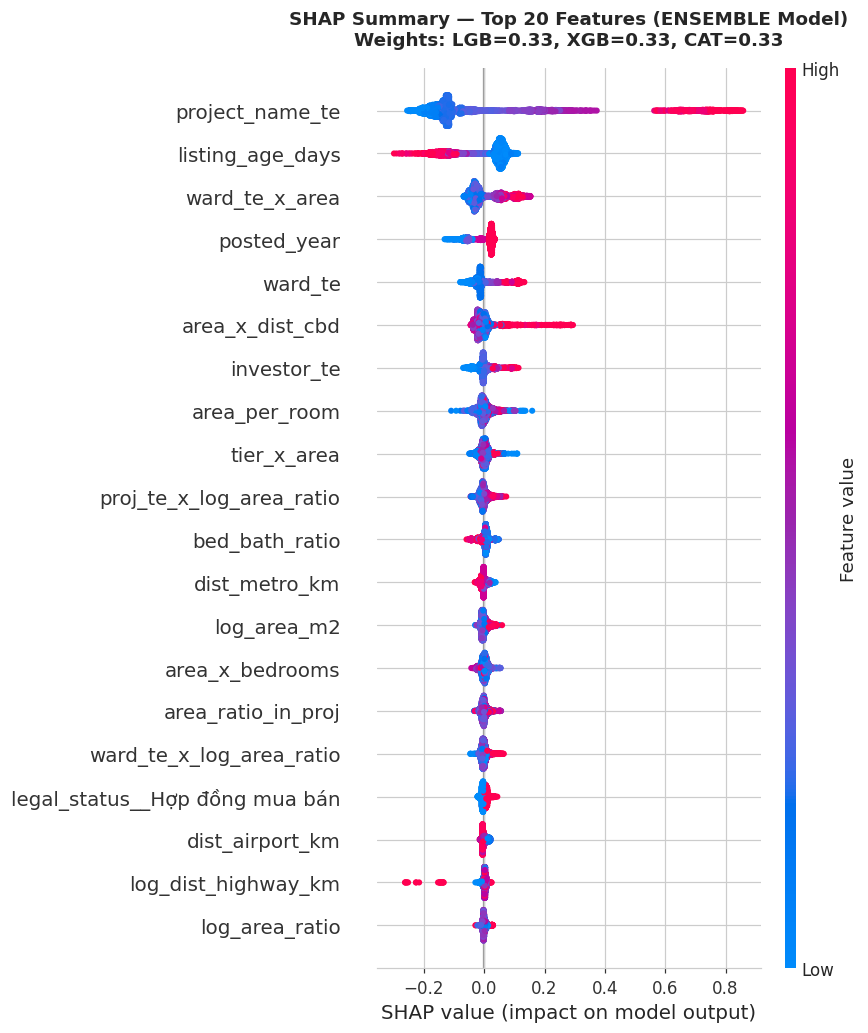


3. Vẽ SHAP Bar Plot...


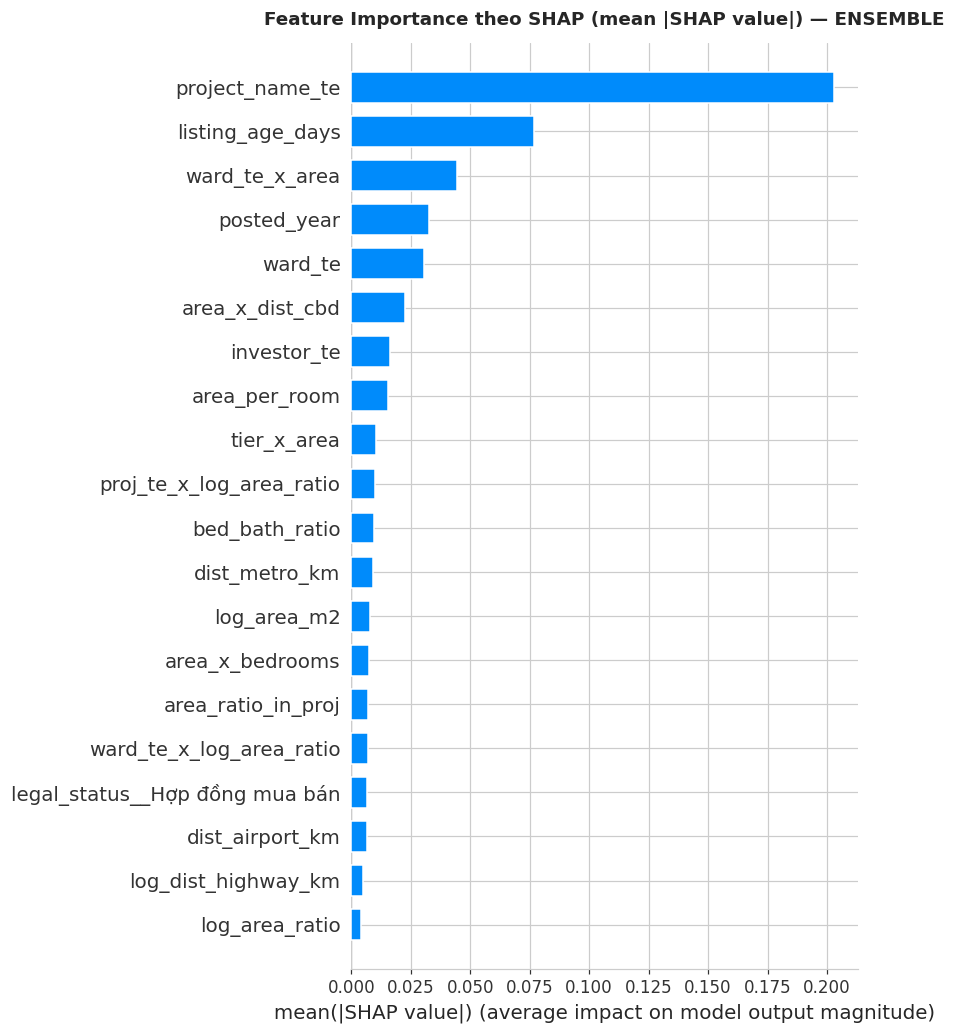


4. Top 15 features theo SHAP importance (Ensemble):

   Rank  Feature                          SHAP_mean
   --------------------------------------------------
    1.   project_name_te                0.20290
    2.   listing_age_days               0.07662
    3.   ward_te_x_area                 0.04454
    4.   posted_year                    0.03255
    5.   ward_te                        0.03037
    6.   area_x_dist_cbd                0.02264
    7.   investor_te                    0.01629
    8.   area_per_room                  0.01557
    9.   tier_x_area                    0.01019
   10.   proj_te_x_log_area_ratio       0.00992
   11.   bed_bath_ratio                 0.00967
   12.   dist_metro_km                  0.00930
   13.   log_area_m2                    0.00800
   14.   area_x_bedrooms                0.00760
   15.   area_ratio_in_proj             0.00717

5. Vẽ SHAP Dependence Plots cho top 4 features...
   Top 4 features: ['project_name_te', 'listing_age_days', 'ward_te_x

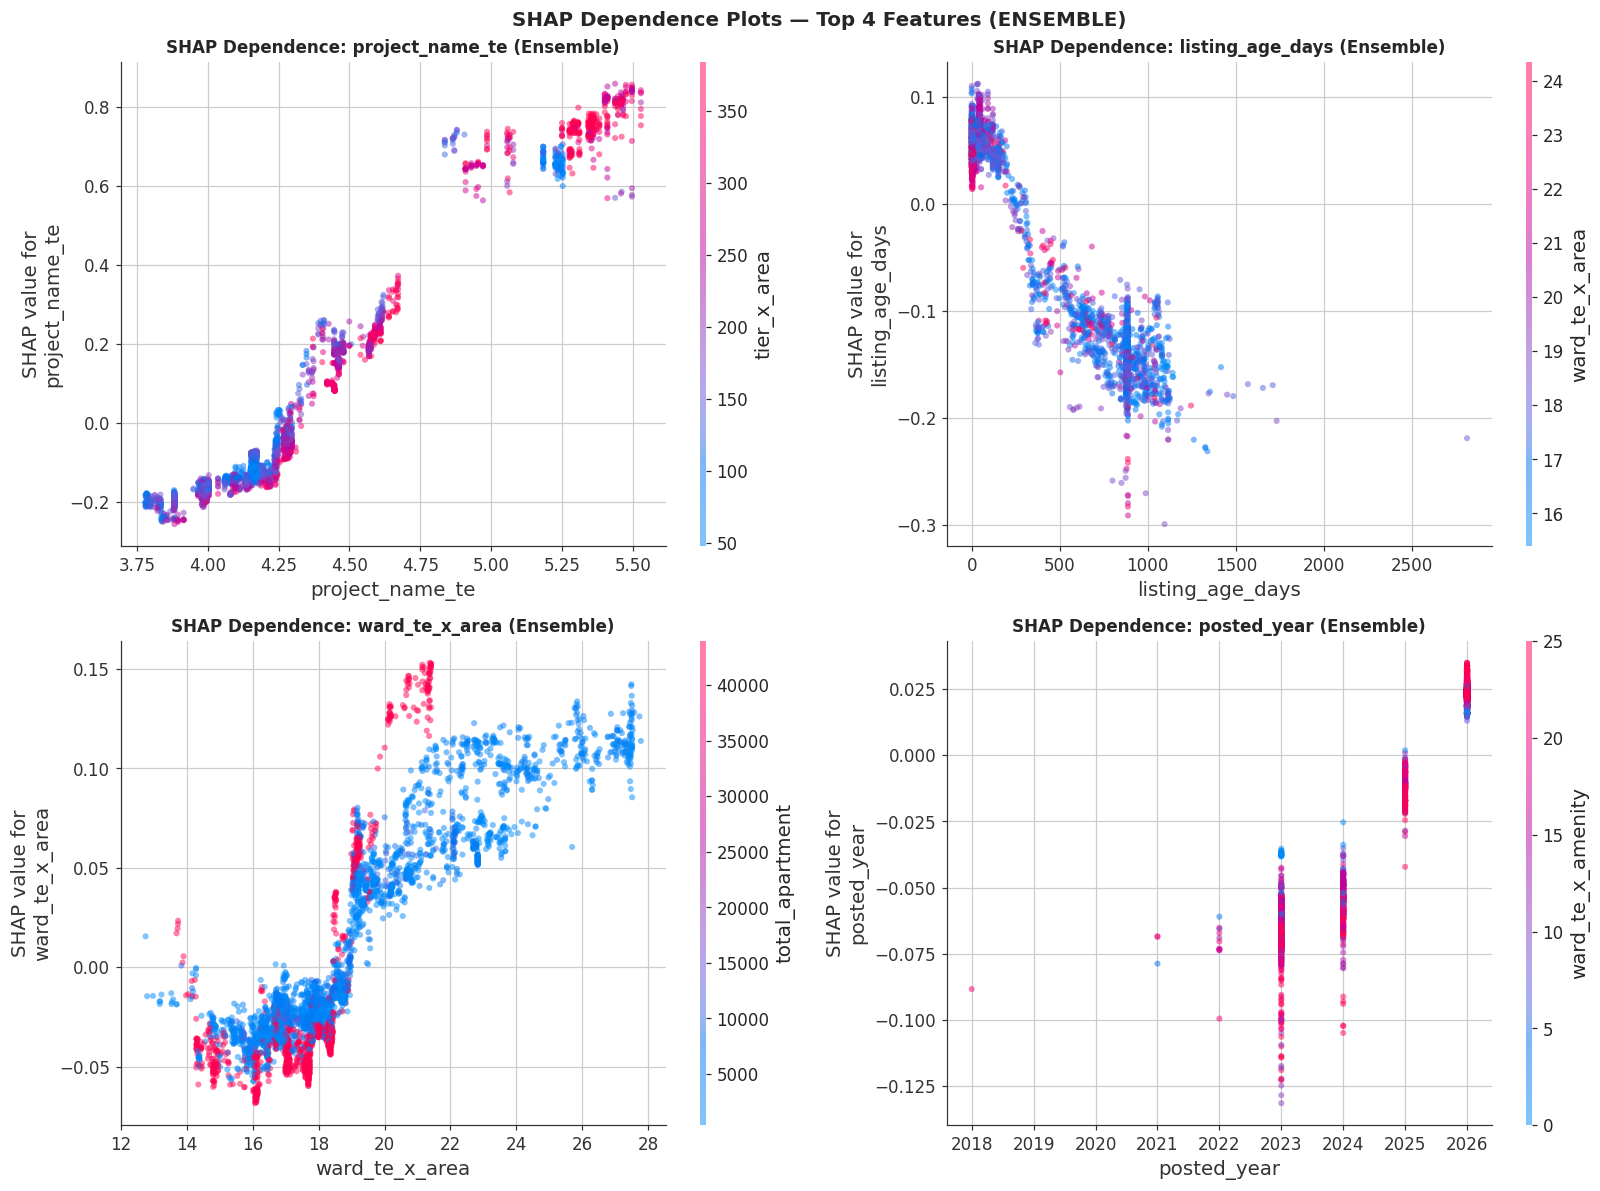


6. Phân tích 3 căn đặc biệt bằng SHAP Waterfall...

   Predict tốt nhất (error=0.0 tr/m²):
     Thực tế: 66.9 tr/m²
     Dự đoán: 66.9 tr/m²


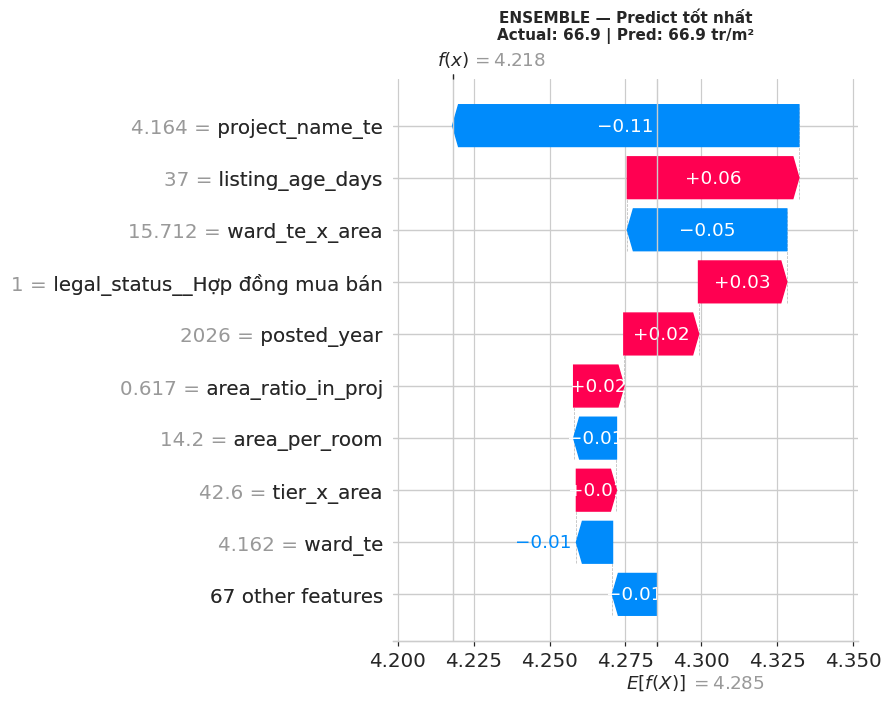


   Predict tệ nhất (error=246.4 tr/m²):
     Thực tế: 626.5 tr/m²
     Dự đoán: 380.1 tr/m²


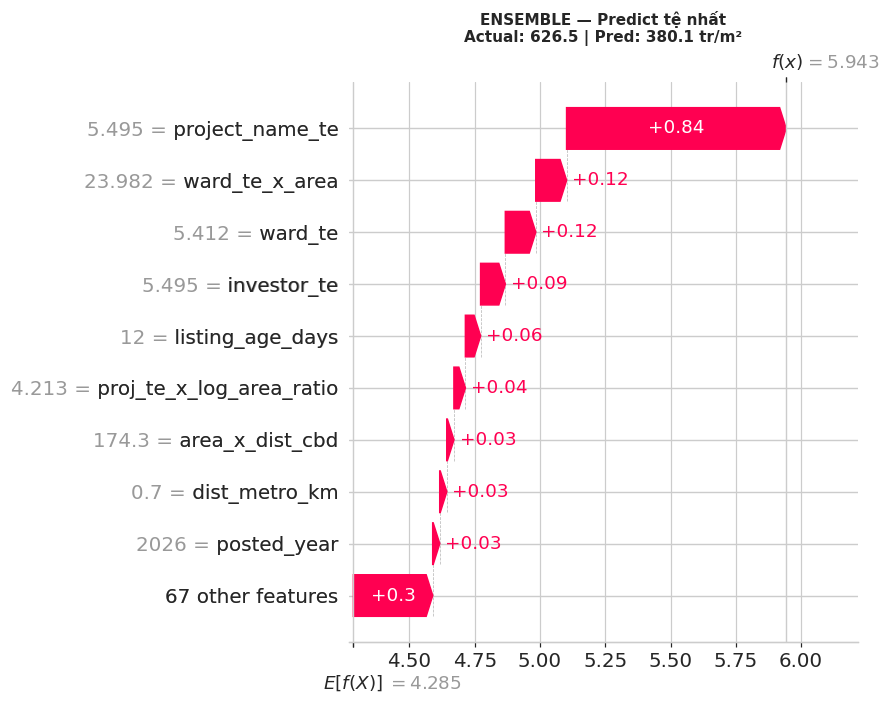


   Predict trung bình (error=3.8 tr/m²):
     Thực tế: 59.3 tr/m²
     Dự đoán: 55.5 tr/m²


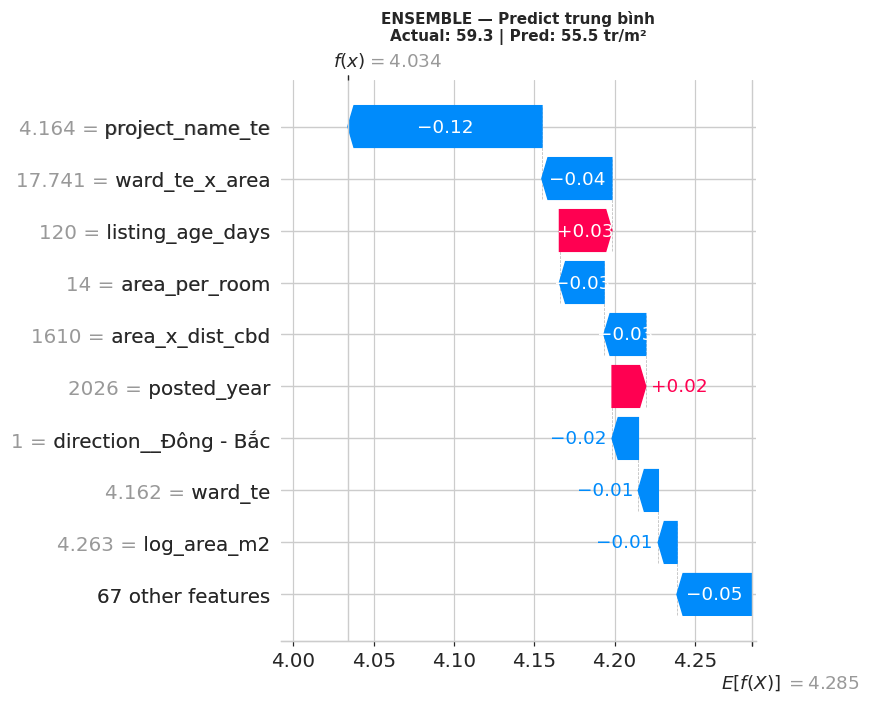


7. Vẽ Error Analysis Plot (Residuals & Actual vs Predicted)...


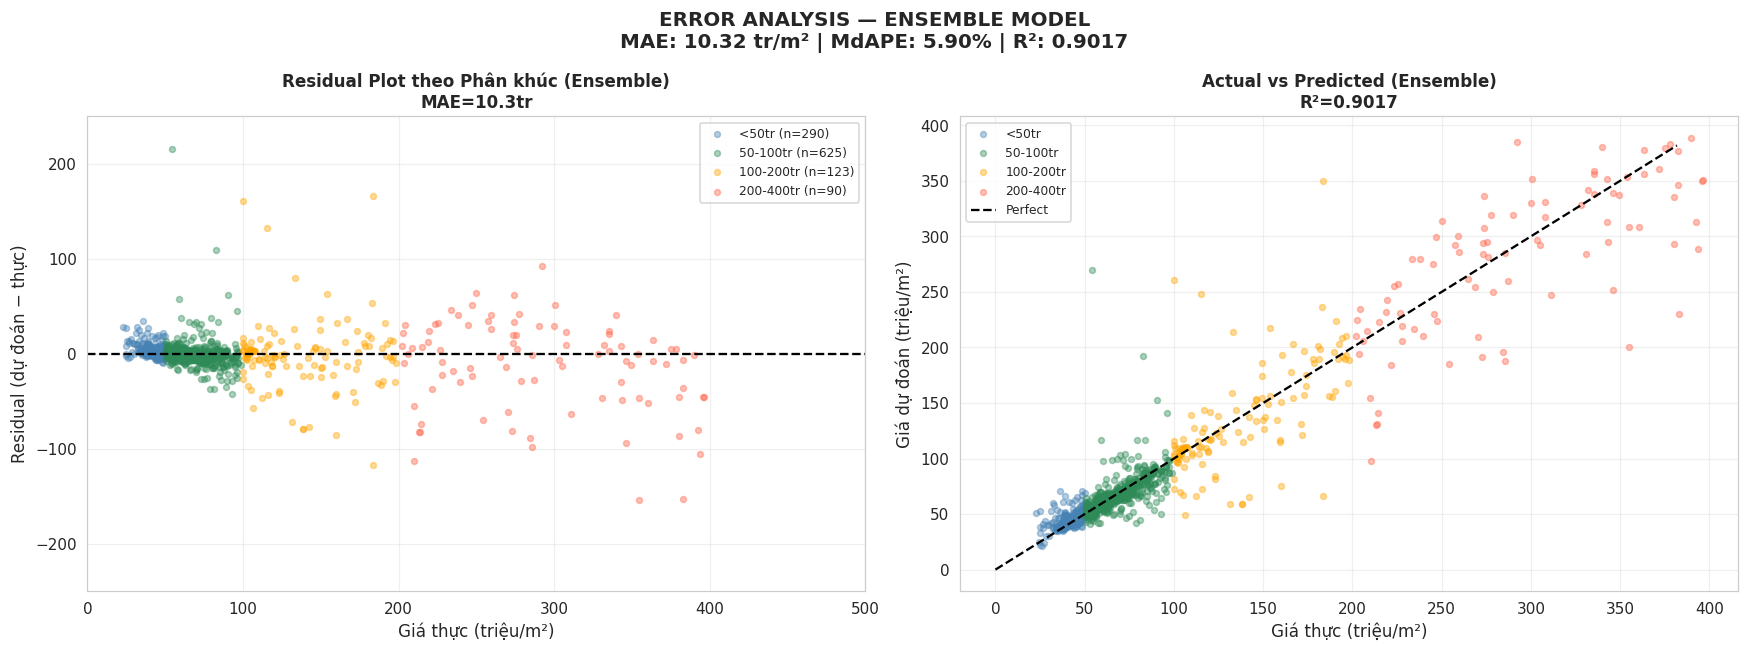


8. Top 10 predictions sai nhiều nhất (Ensemble):
       actual  predicted  abs_error  pct_error    segment
890  626.5100   380.0900   246.4200    39.3300     >400tr
719   54.3500   270.0100   215.6600   396.8100   50-100tr
1110 183.3300   349.4800   166.1500    90.6300  100-200tr
44   100.0000   260.4400   160.4400   160.4400  100-200tr
156  354.8400   200.6000   154.2400    43.4700  200-400tr
384  383.0300   229.8500   153.1900    39.9900  200-400tr
782  115.2900   248.3100   133.0100   115.3700  100-200tr
528  183.3300    66.4100   116.9200    63.7700  100-200tr
690  210.1900    97.6500   112.5400    53.5400  200-400tr
878   82.6700   192.4100   109.7400   132.7500   50-100tr

9. So sánh SHAP importance giữa 3 models:

   Top 10 Features — So sánh importance 3 models:
   ----------------------------------------------------------------------
   Feature                        LGB      XGB      CAT      ENS
   ----------------------------------------------------------------------
   pr

In [ ]:
# ── Cell 15 — SHAP Analysis cho Ensemble Model (không lưu file) ──────────────

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

print("="*70)
print("  SHAP ANALYSIS — ENSEMBLE MODEL (LightGBM + XGBoost + CatBoost)")
print("="*70)

# ── 1. Tính SHAP values cho từng model ──────────────────────────────────────
print("\n1. Tính SHAP values cho từng model...")

# LightGBM SHAP
print("   - LightGBM...")
explainer_lgb = shap.TreeExplainer(lgb_final)
shap_values_lgb = explainer_lgb.shap_values(X_trainval)

# XGBoost SHAP
print("   - XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb_final)
shap_values_xgb = explainer_xgb.shap_values(X_trainval)

# CatBoost SHAP
print("   - CatBoost...")
explainer_cat = shap.TreeExplainer(cat_final)
shap_values_cat = explainer_cat.shap_values(X_trainval)

# Ensemble SHAP = trung bình có trọng số
shap_values_ensemble = (w_lgb * shap_values_lgb + w_xgb * shap_values_xgb + w_cat * shap_values_cat)
shap_X = X_trainval

print(f"   ✓ SHAP values shape (ensemble): {shap_values_ensemble.shape}")
print(f"   ✓ Ensemble weights: LGB={w_lgb:.3f}, XGB={w_xgb:.3f}, CAT={w_cat:.3f}")

# ── 2. SHAP Summary Plot (Beeswarm) ─────────────────────────────────────────
print("\n2. Vẽ SHAP Summary Plot (Beeswarm)...")
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values_ensemble, shap_X,
    max_display=20,
    show=False,
    plot_type="dot"
)
plt.title(f"SHAP Summary — Top 20 Features (ENSEMBLE Model)\n"
          f"Weights: LGB={w_lgb:.2f}, XGB={w_xgb:.2f}, CAT={w_cat:.2f}",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ── 3. SHAP Bar Plot (mean |SHAP|) ──────────────────────────────────────────
print("\n3. Vẽ SHAP Bar Plot...")
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values_ensemble, shap_X,
    max_display=20,
    show=False,
    plot_type="bar"
)
plt.title("Feature Importance theo SHAP (mean |SHAP value|) — ENSEMBLE",
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# ── 4. In top features và SHAP values chi tiết ──────────────────────────────
print("\n4. Top 15 features theo SHAP importance (Ensemble):")
mean_abs_shap = np.abs(shap_values_ensemble).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=shap_X.columns).sort_values(ascending=False)

print("\n   Rank  Feature                          SHAP_mean")
print("   " + "-"*50)
for i, (feat, val) in enumerate(shap_importance.head(15).items(), 1):
    print(f"   {i:2d}.   {feat:<30} {val:.5f}")

# ── 5. SHAP Dependence Plot — top 4 features ────────────────────────────────
print("\n5. Vẽ SHAP Dependence Plots cho top 4 features...")
top4_features = shap_importance.head(4).index.tolist()
print(f"   Top 4 features: {top4_features}")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(top4_features):
    shap.dependence_plot(
        feat, shap_values_ensemble, shap_X,
        ax=axes[i],
        show=False,
        alpha=0.5,
        interaction_index='auto'
    )
    axes[i].set_title(f"SHAP Dependence: {feat} (Ensemble)", fontsize=11, fontweight='bold')

plt.suptitle("SHAP Dependence Plots — Top 4 Features (ENSEMBLE)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. SHAP Waterfall — 3 căn đặc biệt (ensemble predictions) ──────────────
print("\n6. Phân tích 3 căn đặc biệt bằng SHAP Waterfall...")

# Tính ensemble predictions cho test set
def ensemble_predict(X):
    preds = np.column_stack([
        lgb_final.predict(X),
        xgb_final.predict(X),
        cat_final.predict(X)
    ])
    return preds @ [w_lgb, w_xgb, w_cat]  # weighted average

y_pred_log_ensemble = ensemble_predict(X_test)
y_true_real = np.expm1(y_test.values)
y_pred_real_ensemble = np.expm1(y_pred_log_ensemble)
abs_errors = np.abs(y_true_real - y_pred_real_ensemble)

idx_best = abs_errors.argmin()
idx_worst = abs_errors.argmax()
idx_median = np.argsort(abs_errors)[len(abs_errors)//2]

# SHAP values cho test set (ensemble weighted)
shap_values_lgb_test = explainer_lgb.shap_values(X_test)
shap_values_xgb_test = explainer_xgb.shap_values(X_test)
shap_values_cat_test = explainer_cat.shap_values(X_test)
shap_values_ensemble_test = (w_lgb * shap_values_lgb_test +
                              w_xgb * shap_values_xgb_test +
                              w_cat * shap_values_cat_test)

expected_value_ensemble = (w_lgb * explainer_lgb.expected_value +
                           w_xgb * explainer_xgb.expected_value +
                           w_cat * explainer_cat.expected_value)

cases = [
    ("Predict tốt nhất", idx_best, abs_errors[idx_best]),
    ("Predict tệ nhất", idx_worst, abs_errors[idx_worst]),
    ("Predict trung bình", idx_median, abs_errors[idx_median])
]

for title, idx, err in cases:
    print(f"\n   {title} (error={err:.1f} tr/m²):")
    print(f"     Thực tế: {y_true_real[idx]:.1f} tr/m²")
    print(f"     Dự đoán: {y_pred_real_ensemble[idx]:.1f} tr/m²")

    plt.figure(figsize=(14, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_ensemble_test[idx],
            base_values=expected_value_ensemble,
            data=X_test.iloc[idx],
            feature_names=X_test.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f"ENSEMBLE — {title}\n"
              f"Actual: {y_true_real[idx]:.1f} | Pred: {y_pred_real_ensemble[idx]:.1f} tr/m²",
          fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── 7. Error Analysis Plot (Ensemble) ───────────────────────────────────────
print("\n7. Vẽ Error Analysis Plot (Residuals & Actual vs Predicted)...")

residuals = y_pred_real_ensemble - y_true_real
segments = pd.cut(
    y_true_real,
    bins=[0, 50, 100, 200, 400, np.inf],
    labels=['<50tr', '50-100tr', '100-200tr', '200-400tr', '>400tr']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual plot
for seg, color in zip(['<50tr', '50-100tr', '100-200tr', '200-400tr'],
                      ['steelblue', 'seagreen', 'orange', 'tomato']):
    mask = segments == seg
    if mask.sum() < 3: continue
    axes[0].scatter(y_true_real[mask], residuals[mask],
                    alpha=0.4, s=15, color=color, label=f'{seg} (n={mask.sum()})')
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_xlabel('Giá thực (triệu/m²)', fontsize=11)
axes[0].set_ylabel('Residual (dự đoán − thực)', fontsize=11)
axes[0].set_title(f'Residual Plot theo Phân khúc (Ensemble)\nMAE={np.mean(np.abs(residuals)):.1f}tr',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 500)
axes[0].set_ylim(-250, 250)
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
for seg, color in zip(['<50tr', '50-100tr', '100-200tr', '200-400tr'],
                      ['steelblue', 'seagreen', 'orange', 'tomato']):
    mask = segments == seg
    if mask.sum() < 3: continue
    axes[1].scatter(y_true_real[mask], y_pred_real_ensemble[mask],
                    alpha=0.4, s=15, color=color, label=seg)

lim = np.percentile(y_true_real, 99)
axes[1].plot([0, lim], [0, lim], 'k--', lw=1.5, label='Perfect')
axes[1].set_xlabel('Giá thực (triệu/m²)', fontsize=11)
axes[1].set_ylabel('Giá dự đoán (triệu/m²)', fontsize=11)
axes[1].set_title(f'Actual vs Predicted (Ensemble)\nR²={ens_test_r2:.4f}',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'ERROR ANALYSIS — ENSEMBLE MODEL\n'
             f'MAE: {np.mean(np.abs(residuals)):.2f} tr/m² | MdAPE: 5.90% | R²: {ens_test_r2:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 8. Top 10 worst predictions ────────────────────────────────────────────
print("\n8. Top 10 predictions sai nhiều nhất (Ensemble):")
err_df = pd.DataFrame({
    'actual': y_true_real,
    'predicted': y_pred_real_ensemble,
    'abs_error': abs_errors,
    'pct_error': abs_errors / (y_true_real + 1e-6) * 100,
    'segment': segments
})
print(err_df.nlargest(10, 'abs_error').round(2).to_string())

# ── 9. So sánh feature importance giữa 3 models ────────────────────────────
print("\n9. So sánh SHAP importance giữa 3 models:")
importance_compare = pd.DataFrame({
    'LightGBM': np.abs(shap_values_lgb).mean(axis=0),
    'XGBoost': np.abs(shap_values_xgb).mean(axis=0),
    'CatBoost': np.abs(shap_values_cat).mean(axis=0),
    'ENSEMBLE': mean_abs_shap
}, index=shap_X.columns)

# Lấy top 10 ensemble features để so sánh
top10_features = shap_importance.head(10).index
print("\n   Top 10 Features — So sánh importance 3 models:")
print("   " + "-"*70)
print(f"   {'Feature':<25} {'LGB':>8} {'XGB':>8} {'CAT':>8} {'ENS':>8}")
print("   " + "-"*70)
for feat in top10_features:
    print(f"   {feat:<25} {importance_compare.loc[feat, 'LightGBM']:>8.5f} "
          f"{importance_compare.loc[feat, 'XGBoost']:>8.5f} "
          f"{importance_compare.loc[feat, 'CatBoost']:>8.5f} "
          f"{importance_compare.loc[feat, 'ENSEMBLE']:>8.5f}")

# ── 10. Thống kê lỗi theo phân khúc ────────────────────────────────────────
print("\n10. Thống kê lỗi chi tiết theo phân khúc (Ensemble):")
print("    " + "-"*60)
print(f"    {'Segment':<12} {'n':>5} {'MAE':>8} {'MdAPE':>8} {'R²':>8}")
print("    " + "-"*60)

for seg in ['<50tr', '50-100tr', '100-200tr', '200-400tr']:
    mask = segments == seg
    if mask.sum() < 5: continue

    seg_true = y_true_real[mask]
    seg_pred = y_pred_real_ensemble[mask]
    seg_mae = mean_absolute_error(seg_true, seg_pred)
    seg_mdape = np.median(np.abs((seg_true - seg_pred) / (seg_true + 1e-6))) * 100
    seg_r2 = r2_score(seg_true, seg_pred) if mask.sum() > 1 else np.nan

    print(f"    {seg:<12} {mask.sum():>5} {seg_mae:>7.2f}tr {seg_mdape:>7.2f}% {seg_r2:>8.4f}")

print("\n" + "="*70)
print("  SHAP ANALYSIS HOÀN TẤT CHO ENSEMBLE MODEL")
print("="*70)